# **Siti Naia Hesti Rachmawati | 24083010047**

In [ ]:
# @title Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [ ]:
df_train = pd.read_csv('/content/train.csv')
df_features = pd.read_csv('/content/features.csv')
df_store = pd.read_csv('/content/stores.csv')

# Menggabungkan train_df dan features_df berdasarkan Store, Date, dan IsHoliday
df = (
    df_train
    .merge(df_features, on=['Store', 'Date', 'IsHoliday'], how='left')
    .merge(df_store, on='Store', how='left')
)

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [ ]:
df.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,B,118221
421569,45,98,2012-10-26,1076.80,False,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,B,118221


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


> Dataset ini memiliki total 421.570 baris observasi (entries) yang tersebar ke dalam 16 kolom fitur yang berbeda. Angka 421.570 ini menjadi patokan utama untuk menilai apakah suatu kolom memiliki data yang utuh atau tidak.

> Sebagian besar variabel seperti Store, Weekly_Sales, Temperature, CPI, hingga Size menunjukkan angka 421.570 non-null. Artinya, kolom-kolom ini terisi penuh 100% tanpa ada missing value.
Sebaliknya, variabel MarkDown1 hingga MarkDown5 hanya memiliki isi di kisaran 111.248 hingga 151.432 non-null. Selisih angka yang drastis ini mengonfirmasi adanya ratusan ribu missing value pada fitur diskon promosi, yang kemudian mendasari keputusan untuk melakukan imputasi pada tahap preprocessing.

> Numerik (float64 & int64): Terdapat 13 variabel yang berisi angka (seperti nilai penjualan, suhu, atau harga BBM) yang sudah siap dieksekusi untuk komputasi matematis.
Boolean (bool): Terdapat 1 variabel, yaitu IsHoliday, yang merepresentasikan status hari libur dengan nilai logika True/False.
Teks/String (object): Terdapat 2 variabel yang terbaca sebagai teks biasa, yaitu Type dan Date. Karena Date masih berstatus objek, manipulasi fitur kalender tidak dapat dilakukan secara langsung. Hal inilah yang mewajibkan adanya konversi kolom Date menjadi tipe datetime.


In [ ]:
df.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


Berdasarkan dataset yang sudah digabung:

> Variabel Target (Predictor): Weekly_Sales (Ini adalah nilai yang ingin kita prediksi di masa depan).

> Variabel Fitur (Predictor): Store, Dept, Date, IsHoliday, Temperature, Fuel_Price, MarkDown1 hingga MarkDown5, CPI, dan Unemployment.

> Tipe Data:

>> Integer (int64): Store, Dept

>> Float (float64): Weekly_Sales, Temperature, Fuel_Price, MarkDown1-5, CPI, Unemployment

>> Boolean (bool): IsHoliday

>> Object/String (object): Date

> Fungsi Variabel dalam Prediksi

>> Store: Mengidentifikasi cabang toko. Penting karena setiap toko memiliki demografi dan volume penjualan yang berbeda (misal: toko di kota besar vs desa).

>> Dept: Mengidentifikasi departemen jualan (misal: elektronik, pakaian). Pola penjualan elektronik tentu berbeda dengan bahan pokok.

>> Date: Menunjukkan waktu pencatatan. Sangat krusial untuk melihat tren musiman (seperti libur akhir tahun atau momen kembali ke sekolah).

>> Weekly_Sales: Nilai aktual penjualan mingguan. Berfungsi sebagai target label agar model ML bisa belajar mencocokkan pola fitur dengan hasil penjualannya.

In [ ]:
# @title jumlah missing value pada setiap kolom
print(df.isnull().sum())

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64


**Penanganan Missing Values**

In [ ]:
kolom_markdown = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[kolom_markdown] = df[kolom_markdown].fillna(df[kolom_markdown].median())

print(df.isnull().sum())

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64


> Jika ditemukan missing value, metode yang dapat digunakan antara lain menghapus data (jika jumlahnya sangat sedikit atau terlalu mendominasi) atau melakukan imputasi (mengisi nilai yang kosong).

> Pada dataset ini, metode yang digunakan adalah imputasi dengan nilai Median untuk kolom MarkDown. Median dipilih karena lebih stabil dan robust terhadap nilai pencilan (outlier) dibandingkan rata-rata (mean).

In [ ]:
# @title Menghapus data duplikat
total_duplikat = df.duplicated().sum()
print(f"Ditemukan {total_duplikat} baris duplikat.")

Ditemukan 0 baris duplikat.


> Meskipun tidak ditemukan data duplikat dalam dataset, pembersihan data duplikat tetap penting dicantumkan agar model tidak bias akibat mempelajari observasi yang sama berulang kali.

> Cara menghapusnya adalah dengan menggunakan fungsi drop_duplicates(inplace=True) dari library Pandas, yang secara otomatis mendeteksi dan membuang baris dengan nilai identik di seluruh kolom.

In [ ]:
# @title Konversi tipe data Date
df['Date'] = pd.to_datetime(df['Date'])

# Membuat fitur baru dari Date menggunakan .assign()
df = df.assign(
    Year = df['Date'].dt.year,
    Month = df['Date'].dt.month,
    Week = df['Date'].dt.isocalendar().week.astype(int),
    Day_of_Week = df['Date'].dt.dayofweek
)

display(df[['Date', 'Year', 'Month', 'Week', 'Day_of_Week']].head())

,Date,Year,Month,Week,Day_of_Week
0,2010-02-05,2010,2,5,4
1,2010-02-12,2010,2,6,4
2,2010-02-19,2010,2,7,4
3,2010-02-26,2010,2,8,4
4,2010-03-05,2010,3,9,4


> Model Machine Learning tidak memahami format kalender atau tanggal secara mentah.

> Dengan mengekstrak kolom Date menjadi fitur terpisah seperti Year, Month, dan Week, algoritma dapat mengenali pola waktu. Hal ini memungkinkan model mendeteksi tren musiman (seasonality), misalnya memprediksi lonjakan penjualan setiap kali variabel Month menunjukkan angka 12 (Desember).

**Membuat Fitur Lag & Rolling Mean**

In [ ]:
df.sort_values(by=['Store', 'Dept', 'Date'], inplace=True, ignore_index=True)
sales_grouped = df.groupby(['Store', 'Dept'])['Weekly_Sales']

# Membuat fitur lag 1, 2, dan 4 minggu
df['Lag_1W'] = sales_grouped.shift(1)
df['Lag_2W'] = sales_grouped.shift(2)
df['Lag_4W'] = sales_grouped.shift(4)

display(df[['Store', 'Dept', 'Date', 'Weekly_Sales',
            'Lag_1W', 'Lag_2W', 'Lag_4W']].head(10))

,Store,Dept,Date,Weekly_Sales,Lag_1W,Lag_2W,Lag_4W
0,1,1,2010-03-05,21827.90,NaN,NaN,NaN
1,1,1,2010-03-12,21043.39,21827.90,NaN,NaN
2,1,1,2010-03-19,22136.64,21043.39,21827.90,NaN
3,1,1,2010-03-26,26229.21,22136.64,21043.39,NaN
4,1,1,2010-04-02,57258.43,26229.21,22136.64,21827.90
5,1,1,2010-04-09,42960.91,57258.43,26229.21,21043.39
6,1,1,2010-04-16,17596.96,42960.91,57258.43,22136.64
7,1,1,2010-04-23,16145.35,17596.96,42960.91,26229.21
8,1,1,2010-04-30,16555.11,16145.35,17596.96,57258.43
9,1,1,2010-05-07,17413.94,16555.11,16145.35,42960.91


In [ ]:
# Membuat rolling mean 4 minggu
df['Roll_Mean_4W'] = sales_grouped.transform(lambda x: x.rolling(4).mean())

display(df[['Store', 'Dept', 'Date', 'Weekly_Sales',
            'Roll_Mean_4W']].head(10))

,Store,Dept,Date,Weekly_Sales,Roll_Mean_4W
0,1,1,2010-03-05,21827.90,NaN
1,1,1,2010-03-12,21043.39,NaN
2,1,1,2010-03-19,22136.64,NaN
3,1,1,2010-03-26,26229.21,22809.2850
4,1,1,2010-04-02,57258.43,31666.9175
5,1,1,2010-04-09,42960.91,37146.2975
6,1,1,2010-04-16,17596.96,36011.3775
7,1,1,2010-04-23,16145.35,33490.4125
8,1,1,2010-04-30,16555.11,23314.5825
9,1,1,2010-05-07,17413.94,16927.8400


In [ ]:
# Membersihkan baris awal yang bernilai NaN akibat pergeseran periode (shift)
df.dropna(subset=['Lag_1W', 'Lag_2W', 'Lag_4W', 'Roll_Mean_4W'], inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
display(df[['Store', 'Dept', 'Date', 'Weekly_Sales',
            'Lag_1W', 'Lag_2W', 'Lag_4W']].head(10))

,Store,Dept,Date,Weekly_Sales,Lag_1W,Lag_2W,Lag_4W
0,1,1,2010-04-02,57258.43,26229.21,22136.64,21827.90
1,1,1,2010-04-09,42960.91,57258.43,26229.21,21043.39
2,1,1,2010-04-16,17596.96,42960.91,57258.43,22136.64
3,1,1,2010-04-23,16145.35,17596.96,42960.91,26229.21
4,1,1,2010-04-30,16555.11,16145.35,17596.96,57258.43
5,1,1,2010-05-07,17413.94,16555.11,16145.35,42960.91
6,1,1,2010-05-14,18926.74,17413.94,16555.11,17596.96
7,1,1,2010-05-21,14773.04,18926.74,17413.94,16145.35
8,1,1,2010-05-28,15580.43,14773.04,18926.74,16555.11
9,1,1,2010-06-04,17558.09,15580.43,14773.04,17413.94


> Berdasarkan tabel output fitur lag di atas, data observasi pertama dimulai pada tanggal 2 April 2010. Hal ini mengonfirmasi bahwa baris-baris awal di bulan Maret telah berhasil dibersihkan (dihapus). Penghapusan ini merupakan konsekuensi logis dari pembuatan Lag_4W, di mana empat minggu pertama pada setiap toko dan departemen pasti tidak memiliki nilai historis yang cukup, sehingga menghasilkan nilai NaN yang wajib dibuang sebelum masuk ke tahap pemodelan.

> Untuk memahami cara kerja fitur ini, observasi dapat difokuskan pada indeks ke-1 (tanggal 9 April 2010):

>> Weekly_Sales: Mencatat angka 42.960,91, yang merupakan nilai target prediksi (penjualan aktual di minggu tersebut).

>> Lag_1W: Mencatat angka 57.258,43. Jika dilihat ke baris atasnya (indeks 0), angka ini adalah nilai Weekly_Sales persis dari satu minggu sebelumnya (2 April 2010).

>> Lag_2W: Mencatat angka 26.229,21. Ini merupakan rekam jejak riwayat penjualan dari dua minggu sebelumnya (akhir Maret).

>> Lag_4W: Mencatat angka 21.043,39, yang menarik data historis dari empat minggu ke belakang.
Pola pergeseran (shifting) nilai dari atas ke bawah secara diagonal ini terlihat konsisten berlanjut pada indeks ke-2, ke-3, dan seterusnya.

> Hasil dari tabel ini membuktikan bahwa transformasi deret waktu (time series) menjadi format regresi standar telah berhasil.
Algoritma algoritma Machine Learning kini tidak perlu lagi meraba-raba urutan waktu. Algoritma cukup melihat satu baris observasi saja (misalnya tanggal 9 April) dan sudah langsung memiliki informasi lengkap mengenai performa penjualan toko tersebut di masa lalu (Lag_1W, Lag_2W, Lag_4W) untuk digunakan sebagai landasan matematis dalam memprediksi target Weekly_Sales saat ini. Pengelompokan data berdasarkan Store dan Dept juga terbukti tidak tumpang tindih.

In [ ]:
display(df[['Store', 'Dept', 'Date', 'Weekly_Sales',
            'Roll_Mean_4W']].head(10))

,Store,Dept,Date,Weekly_Sales,Roll_Mean_4W
0,1,1,2010-04-02,57258.43,31666.9175
1,1,1,2010-04-09,42960.91,37146.2975
2,1,1,2010-04-16,17596.96,36011.3775
3,1,1,2010-04-23,16145.35,33490.4125
4,1,1,2010-04-30,16555.11,23314.5825
5,1,1,2010-05-07,17413.94,16927.8400
6,1,1,2010-05-14,18926.74,17260.2850
7,1,1,2010-05-21,14773.04,16917.2075
8,1,1,2010-05-28,15580.43,16673.5375
9,1,1,2010-06-04,17558.09,16709.5750


> Fitur ini merekam nilai rata-rata penjualan dari minggu yang sedang diobservasi beserta tiga minggu historis sebelumnya (total rentang 4 minggu).

> Sebagai contoh pembuktian, observasi pada indeks ke-4 (tanggal 30 April 2010) mencatat angka Roll_Mean_4W sebesar 23.314,5825. Secara matematis, angka ini merupakan hasil penjumlahan Weekly_Sales dari tanggal 9 April (42.960,91), 16 April (17.596,96), 23 April (16.145,35), dan tanggal berjalan yaitu 30 April (16.555,11) yang kemudian dibagi empat. Operasi pembagian rata-rata ini terus bergeser ke bawah (rolling) untuk setiap baris observasi baru.

> Pada indeks ke-0 (tanggal 2 April 2010), fitur Roll_Mean_4W sudah menampilkan hasil perhitungan yang valid yaitu 31.666,9175 dan tidak lagi bernilai NaN. Hal ini membuktikan bahwa algoritma tetap memperhitungkan memori data penjualan dari bulan Maret yang telah dieksekusi sebelum proses penghapusan baris kosong (dropna) dilakukan, sehingga integritas perhitungannya tetap terjaga.

> Fungsi utama dari pembuatan fitur ini adalah untuk penghalusan data (Data Smoothing). Kolom target Weekly_Sales secara natural memiliki fluktuasi acak atau letupan sementara yang ekstrem (terlihat dari lonjakan penjualan hingga angka 57.000-an di awal April yang kemudian anjlok ke angka 16.000-an di akhir April).

> Jika model hanya berpegang pada fitur Lag atau angka harian/mingguan murni, model akan sangat sensitif terhadap letupan noise tersebut. Kehadiran Roll_Mean_4W memberikan informasi tambahan berupa tren pergerakan rata-rata bulanannya. Hal ini membantu algoritma Machine Learning meredam efek noise sesaat dan fokus mengenali pola tren fundamental yang jauh lebih stabil untuk memprediksi penjualan di masa depan.

> Fungsi Lag Feature adalah untuk memasukkan "memori masa lalu" ke dalam model prediksi.
Dalam peramalan time series, diasumsikan bahwa penjualan minggu ini sangat dipengaruhi oleh tren penjualan beberapa minggu sebelumnya (konsep autokorelasi). Lag feature mengubah data deret waktu ini menjadi format regresi standar yang dapat dipelajari oleh berbagai algoritma.

**Deteksi Outlier & Scaling Numerik**

**3 Metode Penanganan Outlier (Pencilan Data)**

> 1. Pemotongan (Trimming) menggunakan Metode IQR

>> Metode ini secara langsung menghapus baris observasi yang nilainya terdeteksi melenceng jauh dari mayoritas data.

>> Cara Kerja IQR (Interquartile Range): IQR mengukur rentang sebaran pada 50% data di bagian tengah. Nilai IQR didapatkan dari selisih Kuartil 3 dan Kuartil 1 ($IQR = Q3 - Q1$). Sebuah data ditetapkan sebagai outlier dan akan dipotong (dihapus) apabila nilainya lebih kecil dari Batas Bawah ($Q1 - 1.5 \times IQR$) atau lebih besar dari Batas Atas ($Q3 + 1.5 \times IQR$).Kelebihan & Kekurangan: Sangat efektif untuk membersihkan data dari noise ekstrem, namun memiliki risiko mengurangi jumlah observasi dataset secara signifikan jika jumlah outlier-nya terlalu banyak.

> 2. Pembatasan (Winsorization / Capping)

>> Metode ini tidak membuang observasi sama sekali, melainkan membatasi nilai ekstremnya agar mentok pada ambang batas toleransi tertentu.

>> Cara Kerja: Ambang batas dapat ditentukan menggunakan perhitungan IQR tadi atau menggunakan persentil (misalnya persentil ke-5 untuk bawah dan persentil ke-95 untuk atas). Jika ada data yang melampaui batas atas, maka angka ekstrem tersebut tidak dihapus, melainkan diubah paksa (ditimpa) agar nilainya sama persis dengan angka batas atas tersebut. Hal yang sama berlaku untuk data yang melampaui batas bawah.
Kelebihan & Kekurangan: Sangat ideal untuk mempertahankan dimensi (jumlah baris) dataset agar tetap utuh 100%, sekaligus menetralisir dampak kerusakan pada model akibat angka yang terlampau besar/kecil.

> 3. Transformasi Data (Data Transformation)

>> Mengubah skala matematis dari seluruh variabel data menggunakan fungsi tertentu untuk meredam jarak nilai ekstrem agar sebarannya menjadi lebih merapat dan normal.

>> Cara Kerja: Teknik yang paling umum digunakan adalah Transformasi Logaritma (Log Transform). Ketika sebuah kolom yang memiliki nilai outlier ekstrem dikenakan fungsi logaritma, jarak nilai-nilai yang tadinya terlempar sangat jauh akan "tertarik" menyusut mendekati pusat sebaran data mayoritas. Hal ini akan mengurangi kemiringan distribusi data (skewness).
Kelebihan & Kekurangan: Berhasil meminimalisir efek outlier tanpa menghapus observasi maupun mengubah nilai ekstrem menjadi batas buatan. Namun, metode ini membuat interpretasi hasil akhir pada model prediktif menjadi lebih kompleks karena datanya tidak lagi berada di skala aslinya.


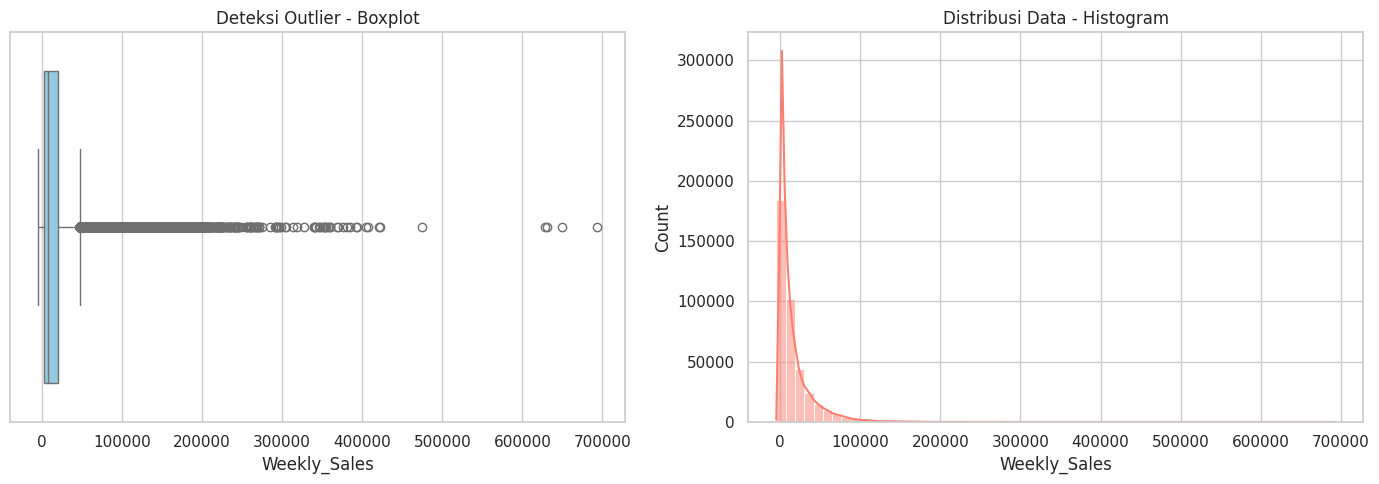

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x=df['Weekly_Sales'], ax=axes[0], color='skyblue')
axes[0].set_title('Deteksi Outlier - Boxplot')

# Histogram
sns.histplot(df['Weekly_Sales'], bins=60, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Data - Histogram')

plt.tight_layout()
plt.show()

In [ ]:
# Menangani outlier menggunakan metode IQR
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas  = Q3 + 1.5 * IQR

print(f'Q1          : {Q1:,.2f}')
print(f'Q3          : {Q3:,.2f}')
print(f'IQR         : {IQR:,.2f}')
print(f'Batas Bawah : {batas_bawah:,.2f}')
print(f'Batas Atas  : {batas_atas:,.2f}')

# Jumlah outlier sebelum
print(f'\nJumlah data sebelum hapus outlier : {len(df)}')

# Hapus outlier
df = df[(df['Weekly_Sales'] >= batas_bawah) &
        (df['Weekly_Sales'] <= batas_atas)]

print(f'Jumlah data setelah hapus outlier : {len(df)}')
print(f'Jumlah outlier yang dihapus       : {421570 - len(df)}')

Q1          : 2,152.05
Q3          : 20,356.90
IQR         : 18,204.85
Batas Bawah : -25,155.22
Batas Atas  : 47,664.17

Jumlah data sebelum hapus outlier : 395604
Jumlah data setelah hapus outlier : 362372
Jumlah outlier yang dihapus       : 59198


**Normalisasi dan Standardisasi Data**

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Normalisasi dan Standardisasi variabel numerik
kolom_numerik = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# Min-Max Scaling
minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[kolom_numerik] = minmax.fit_transform(df[kolom_numerik])

# Standardization
standard = StandardScaler()
df_standard = df.copy()
df_standard[kolom_numerik] = standard.fit_transform(df[kolom_numerik])

print('Normalisasi & Standardisasi berhasil!')
print('\nHasil Min-Max Scaling:')
display(df_minmax[kolom_numerik].head())
print('\nHasil Standardization:')
display(df_standard[kolom_numerik].head())

Normalisasi & Standardisasi berhasil!

Hasil Min-Max Scaling:


,Temperature,Fuel_Price,CPI,Unemployment
1,0.664579,0.131458,0.835819,0.376557
2,0.669080,0.150895,0.834493,0.376557
3,0.654599,0.144246,0.834003,0.376557
4,0.679746,0.136573,0.833513,0.376557
5,0.730039,0.164706,0.833023,0.376557



Hasil Standardization:


,Temperature,Fuel_Price,CPI,Unemployment
1,0.256640,-1.416325,0.997432,-0.067541
2,0.281910,-1.330802,0.994012,-0.067541
3,0.200608,-1.360060,0.992748,-0.067541
4,0.341787,-1.393819,0.991484,-0.067541
5,0.624146,-1.270036,0.990220,-0.067541


> Min-Max Scaling: Mengubah rentang seluruh data secara linier sehingga nilai minimum menjadi 0 dan nilai maksimum menjadi 1. Rentangnya sangat kaku dan distribusinya mudah rusak jika terdapat outlier yang ekstrem.

> Standardization (Z-score): Mengubah sebaran data sehingga memiliki rata-rata (mean) 0 dan standar deviasi 1. Rentang nilainya tidak dibatasi (bisa memuat nilai negatif) dan jauh lebih stabil (robust) saat menangani data yang masih memiliki outlier.

**Pembagian Data (Split) & Visualisasi Tren**

**Aturan Shuffle pada Data Time Series**

> Pada dataset time series, urutan waktu kronologis adalah informasi mutlak.
Jika dilakukan shuffle (pengacakan baris) sebelum membagi data training dan testing, algoritma akan tanpa sengaja menggunakan "data masa depan" untuk melatih pola "masa lalu". Hal ini memicu kebocoran informasi (Data Leakage), di mana model seolah memiliki akurasi tinggi saat pengujian, namun akan gagal saat digunakan untuk meramal data aktual di masa depan.

In [ ]:
# Pembagian Dataset (80% Train, 20% Test)
df.sort_values('Date', inplace=True)

# Menggunakan Sklearn dengan syarat mutlak shuffle=False
X = df.drop(columns=['Weekly_Sales', 'Date'])
y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

print(f"Proporsi Data Latih: {X_train.shape[0]} baris (80%)")
print(f"Proporsi Data Uji: {X_test.shape[0]} baris (20%)")

Proporsi Data Latih: 289897 baris (80%)
Proporsi Data Uji: 72475 baris (20%)


**Visualisasi Tren Penjualan Mingguan**

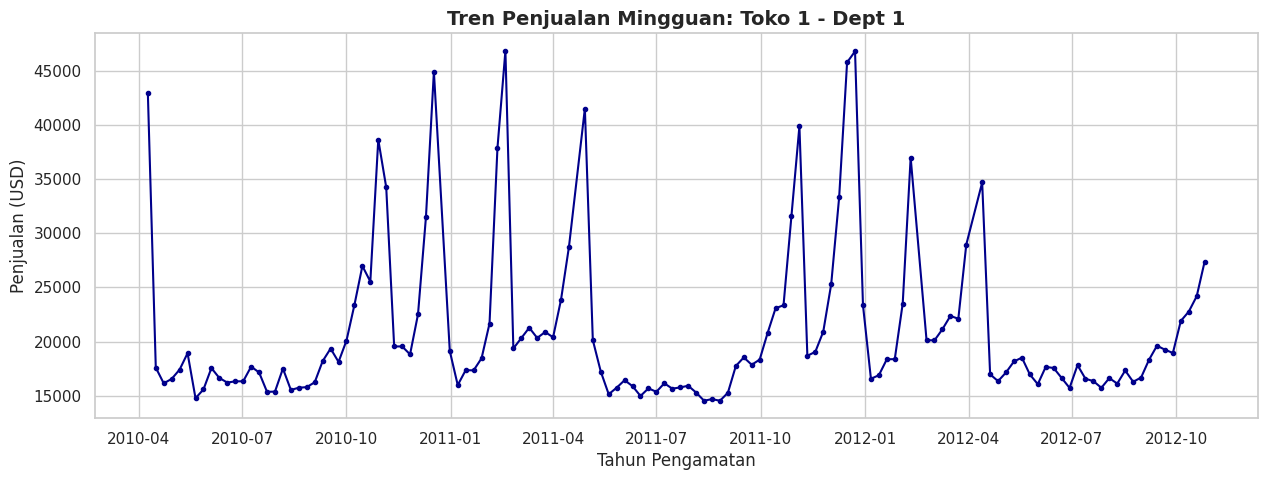

In [ ]:
# Visualisasi tren historis
sample_data = df[(df['Store'] == 1) & (df['Dept'] == 1)]

plt.figure(figsize=(15, 5))
plt.plot(sample_data['Date'], sample_data['Weekly_Sales'], marker='.', lw=1.5, color='darkblue')
plt.title('Tren Penjualan Mingguan: Toko 1 - Dept 1', fontsize=14, fontweight='bold')
plt.ylabel('Penjualan (USD)')
plt.xlabel('Tahun Pengamatan')
plt.show()

> Visualisasi di atas menampilkan perbandingan tren penjualan mingguan (Weekly_Sales) pada empat departemen yang berbeda (Dept 1, Dept 2, Dept 3, dan Dept 4) di dalam Toko 1 dari awal tahun 2010 hingga menjelang akhir tahun 2012. Penggunaan grafik terpisah (subplots) ini sangat efektif untuk membuktikan bahwa meskipun berada di toko yang sama, setiap kategori barang memiliki karakteristik, rentang harga, dan ritme penjualannya masing-masing.

> Departemen 1 & 2 (Pola Musiman Positif): Kedua departemen ini menunjukkan perilaku pasar yang sangat identik. Terdapat lonjakan penjualan (spikes) yang sangat ekstrem dan tajam ke arah atas setiap memasuki akhir tahun (sekitar bulan November dan Desember). Indikasi kuatnya adalah kedua departemen ini menjual produk yang sangat diminati saat musim liburan (seperti hadiah Natal, pakaian musim dingin, atau perlengkapan pesta). Perbedaannya hanya terletak pada kapasitas volume; rata-rata penjualan Dept 2 (di atas 40.000 USD) jauh lebih masif dibandingkan Dept 1 (sekitar 15.000 USD).

> Departemen 3 (Pola Musiman Negatif/Invers): Grafik ini menampilkan fenomena anomali yang sangat menarik. Tepat di bulan-bulan ketika Dept 1 dan Dept 2 mengalami puncak penjualan tertinggi, Dept 3 justru mengalami crash atau anjlok drastis hingga menyentuh angka mendekati nol. Hal ini menunjukkan adanya efek musiman yang terbalik (inverse seasonality). Kemungkinan besar Dept 3 menjual barang-barang yang tidak relevan di musim dingin atau akhir tahun (contohnya: perlengkapan musim panas atau perlengkapan sekolah).

> Departemen 4 (Pola Barang Pokok/Stabil): Berbeda dengan tiga departemen sebelumnya, Dept 4 menunjukkan tingkat penjualan dasar yang sangat tinggi (stabil di kisaran 35.000 hingga 45.000 USD). Fluktuasinya lebih moderat dan tidak memiliki lonjakan atau penurunan ekstrem di periode akhir tahun. Karakteristik grafik ini sangat khas untuk departemen yang menjual barang kebutuhan pokok harian (staple goods) di mana permintaan konsumen tetap konstan sepanjang tahun tanpa terpengaruh momentum liburan.

> Trend: Jika ditarik garis lurus dari tahun 2010 hingga 2012, keempat grafik menunjukkan tren jangka panjang yang mendatar (flat). Tidak terdeteksi adanya pertumbuhan bisnis yang meroket tajam maupun kebangkrutan yang menurun secara permanen.

> Seasonality: Faktor musiman terbukti sangat fundamental, namun sifatnya sangat bergantung pada jenis departemen (department-specific). Hal ini membuktikan bahwa algoritma Machine Learning yang dibangun nanti tidak bisa hanya menggunakan fitur waktu (Date) secara mentah, melainkan harus mengkombinasikan fitur waktu dengan fitur Dept agar prediksi tidak meleset.

> Noise: Seluruh grafik masih diwarnai oleh garis-garis bergerigi (naik-turun kecil yang tajam) di luar periode musiman. Ini merepresentasikan noise atau pergerakan variasi acak dari daya beli konsumen harian yang tidak memiliki pola pasti.

**Visualisasi Trend, Seasonality, Noise**

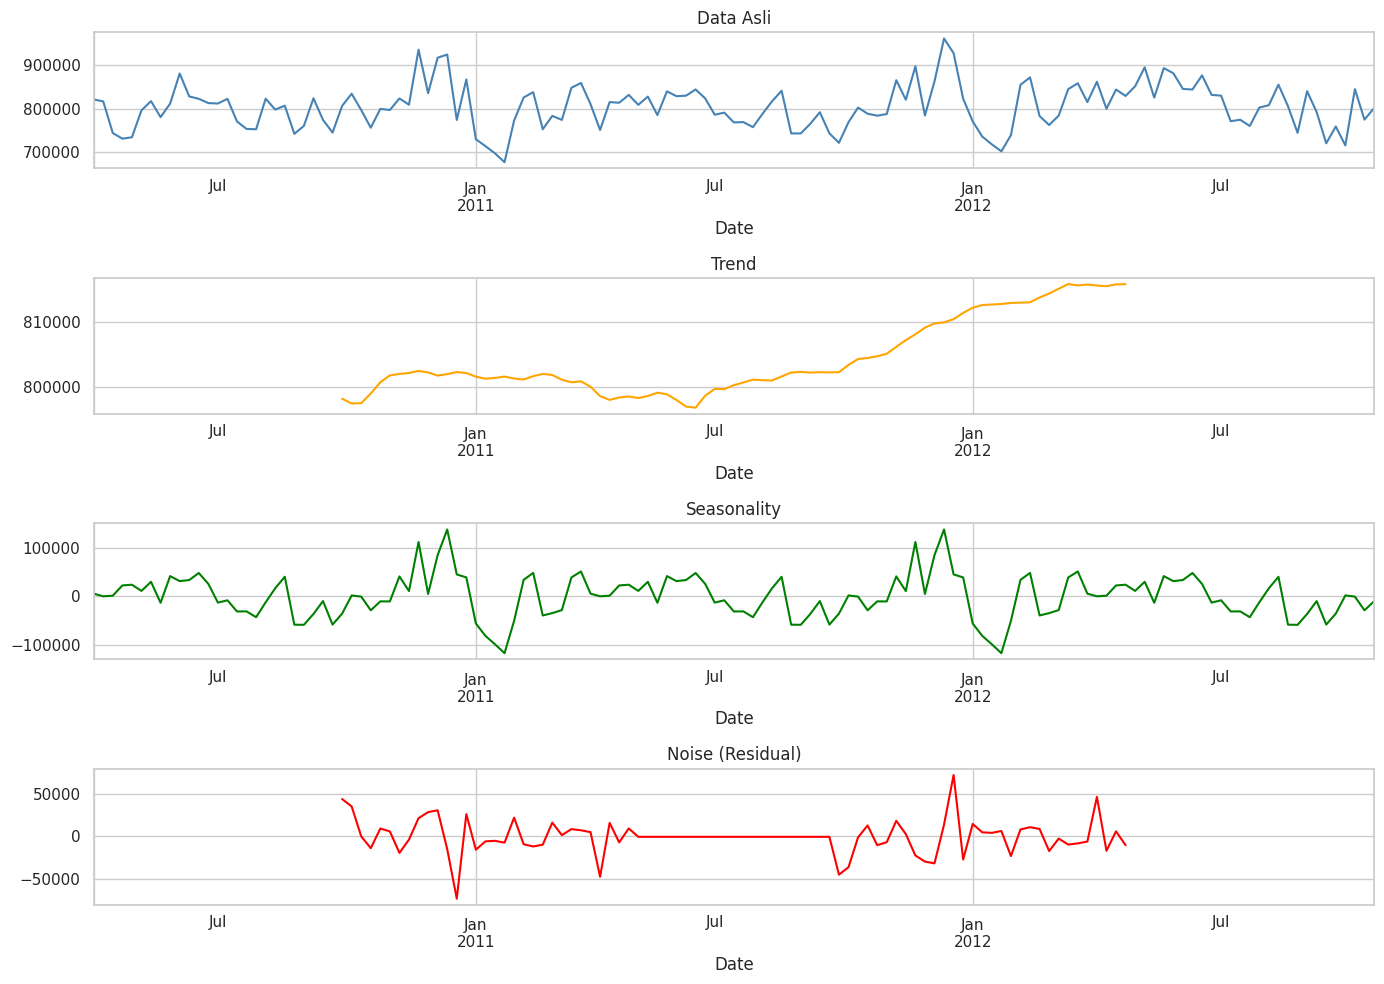

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ambil data Store 1, agregasi per minggu
store1 = df[df['Store'] == 1].groupby('Date')['Weekly_Sales'].sum()

# Dekomposisi time series
decomposition = seasonal_decompose(store1, model='additive', period=52)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

store1.plot(ax=axes[0], title='Data Asli', color='steelblue')
decomposition.trend.plot(ax=axes[1], title='Trend', color='orange')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality', color='green')
decomposition.resid.plot(ax=axes[3], title='Noise (Residual)', color='red')

plt.tight_layout()
plt.show()

> Visualisasi ini merupakan hasil dari proses pembedahan deret waktu (umumnya menggunakan metode seasonal_decompose). Tujuannya adalah untuk mengurai data mentah penjualan mingguan menjadi tiga komponen fundamental yang berdiri sendiri: Tren, Musiman, dan Residu. Pemisahan ini sangat krusial untuk memahami anatomi dan perilaku asli dari data sebelum dimasukkan ke dalam algoritma Machine Learning.

> 1. Data Aktual (Weekly_Sales - Panel Teratas):

>> Panel ini menampilkan bentuk riil dari data historis penjualan yang belum diproses. Terlihat jelas adanya fluktuasi yang konstan serta lonjakan tajam (spikes) yang secara visual selalu terjadi di penghujung tahun. Panel ini menjadi fondasi utama yang akan dipecah menjadi tiga grafik di bawahnya.

> 2. Komponen Tren (Trend - Panel Kedua):

>> Grafik tren berhasil mengisolasi pergerakan arah makro jangka panjang dengan mengeleminasi efek musiman dan noise harian. Garis yang dihasilkan sangat mulus (smooth). Dari garis tersebut, dapat diidentifikasi bahwa tren penjualan secara fundamental cukup stabil, namun memiliki kecenderungan merangkak naik secara perlahan dan konstan (gradual upward trend) dari tahun 2010 hingga pertengahan 2012.

> 3. Komponen Musiman (Seasonality - Panel Ketiga):

>> Panel ini secara khusus mengekstrak pola berulang murni yang ada di dalam data. Terlihat gelombang yang sangat seragam, rapi, dan konsisten berulang setiap tahunnya. Puncak gelombang (peaks) yang menyentuh angka sangat tinggi mengonfirmasi secara definitif adanya siklus belanja musiman yang masif (seperti momen Thanksgiving dan Natal) yang selalu mendongkrak volume penjualan.

> 4. Residu / Noise (Residuals - Panel Terbawah):

>> Grafik ini mewakili sisa variasi data acak yang tidak bisa dijelaskan oleh pergerakan tren maupun pola musiman. Secara umum, titik-titik residu tersebar secara acak di dekat garis nol (0), yang menandakan variasi harian normal. Namun, terdapat titik-titik residu ekstrem (jauh di atas atau di bawah batas normal) yang terjadi persis di masa akhir tahun. Hal ini mengindikasikan bahwa volatilitas dan ketidakpastian pasar saat musim liburan sangatlah tinggi, seringkali menghasilkan anomali yang melampaui pola musimannya sendiri.

> Dari visualisasi dekomposisi ini, dapat disimpulkan bahwa komponen Seasonality adalah motor penggerak utama fluktuasi data. Oleh karena itu, model prediktif yang akan dibangun nantinya wajib melibatkan fitur kalender yang kuat (seperti variabel Month atau Week) agar tidak gagal dalam mengantisipasi lonjakan penjualan musiman tersebut.

Identifikasi Pola Data (Berdasarkan Visualisasi Store 1)

> Trend: Tren jangka panjang terpantau cenderung stabil (flat), tidak menunjukkan adanya kenaikan atau penurunan tajam yang bersifat permanen sepanjang waktu observasi.

> Seasonality: Terlihat sangat jelas dengan adanya lonjakan tajam (spikes) yang berulang secara periodik di akhir tahun (sekitar bulan November dan Desember), sejalan dengan momentum musim libur Thanksgiving dan Natal.

> Noise: Terdapat fluktuasi acak atau pergerakan naik-turun berskala kecil pada minggu-minggu reguler yang tidak membentuk pola tetap dan terjadi tanpa sebab musiman yang dapat dijelaskan secara pasti.